# Sentiment Analysis (Phân tích cảm xúc) – Homi Shop ML Service

Notebook mô phỏng phương pháp xếp loại Review được triển khai trong module `ml_service/app/services/sentiment_service.py`.

## Tổng quan kỹ thuật

Thay vì áp dụng các model Deep Learning quá phức tạp cho các đánh giá thương mại điện tử khá theo khuôn mẫu, hệ thống áp dụng kỹ thuật **Rule-based heuristic (Luật đoán nhanh trực tiếp)** mang lại sự chính xác tuyệt đối, thời gian phản hồi ở mức mili-giây, cực kì ít tài nguyên và dễ dàng cập nhật.

Thuật toán kết hợp song song 2 luồng dữ liệu thô từ Comment:
- **Phân tích từ Vựng (NLP Keyword Matching)**: Nhận biết tập hợp Positive/Negative Vocab (ví dụ: 'Tuyệt', 'Lởm', 'Giá tốt').
- **Tín hiệu số học (Star Ratings)**: Bóc tách điểm số từ 1–5 sao của User.

**Quy hoạch nhãn đích:** Thuật toán phân luồng và kết xuất ra nhãn **Good (Tích cực)** hoặc **Bad (Tiêu cực)** đính kèm với một thang xác suất `confidence score` chạy từ 0 đến 1.0.

## 1. Thiết lập môi trường
Để thực hiện các phân tích này, nhóm sử dụng các công cụ phổ biến trong khoa học dữ liệu:
- **Pandas & Numpy**: Xử lý dữ liệu dạng bảng và ma trận số một cách hiệu quả.
- **Matplotlib & Seaborn**: Vẽ biểu đồ và heat map trực quan.

> **Lưu ý**: Chạy cell này trước tiên để setup Pandas, Numpy, Scikit-learn và các công cụ hiển thị.

In [1]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'matplotlib', 'seaborn', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('Thư viện đã sẵn sàng')

Thư viện đã sẵn sàng


## 2. Nạp dữ liệu
Dữ liệu được trích xuất từ database PostgreSQL của Homi Shop (đưới dạng file CSV) bao gồm các bảng chính luôn liên kết chặt chẽ với nhau:
1. **Sản phẩm (Products)**: Chứa toàn bộ thông tin chi tiết về sản phẩm (tên, giá, đặc tính).
2. **Đánh giá (Reviews)**: Chứa các đánh giá của người dùng về sản phẩm, bao gồm cả điểm số sao và bình luận văn bản.

In [2]:
reviews_raw  = pd.read_csv('furniture_shop.reviews.csv')
products_raw = pd.read_csv('furniture_shop.products.csv')

print(f'Reviews : {len(reviews_raw)}')
print(f'Products: {len(products_raw)}')
reviews_raw[['_id','product','user','rating','comment']].head()

Reviews : 46
Products: 13


,_id,product,user,rating,comment
0,22fb3331d2d37e4554dff67c,6933c4202ea2861093a39b34,b147c5a48776c6549027856c,5,"rat tot, yeu thich mau sac va do ben"
1,1be3094c137ea70682b7ced8,6933c69f2ea2861093a39b3d,b147c5a48776c6549027856c,4,"good quality, hai long, worth the money"
2,982758f693541b2894409746,6933d83cf17e1b6d5ec15b0b,b147c5a48776c6549027856c,3,o muc chap nhan duoc cho tam gia
3,7656563c180802f863cf0636,6933adafb53918b85561127a,b147c5a48776c6549027856c,4,"great product, recommend for family use"
4,73bece9989e05fd4355a3b07,6933cfb22ea2861093a39b5b,50d83bf3615543cb3a606532,4,"good quality, hai long, worth the money"


## 3. Bộ từ điển gốc (Dictionary-based Sentiment)

Từ vựng được chuẩn bị cứng bằng tiếng việt, quét để nhận diện thái độ hài lòng hoặc cau có.

In [3]:
POSITIVE_WORDS = {
    'tot', 'dep', 'hai long', 'chat luong', 'xuat sac',
    'yeu thich', 'recommend', 'good', 'great', 'excellent', 'worth'
}

NEGATIVE_WORDS = {
    'te', 'kem', 'that vong', 'khong hai long', 'vo',
    'xau', 'bad', 'poor', 'terrible', 'worst', 'not good'
}

print('Positive words:', sorted(POSITIVE_WORDS))
print('Negative words:', sorted(NEGATIVE_WORDS))

Positive words: ['chat luong', 'dep', 'excellent', 'good', 'great', 'hai long', 'recommend', 'tot', 'worth', 'xuat sac', 'yeu thich']
Negative words: ['bad', 'kem', 'khong hai long', 'not good', 'poor', 'te', 'terrible', 'that vong', 'vo', 'worst', 'xau']


## 4. Lõi suy luận `sentiment_label()`

Quy tắc quyết định cuối cùng được gộp nhóm qua khối If/Else tinh nghịch:
1. Khảo sát điểm Semantic: `Positive Words count - Negative Words count`.
2. Chốt tín hiệu từ số Rating (Trên 4 là uy tín, nhỏ hơn 2 là thảm họa).
3. Tính mức độ tự tin (Confidence) tăng tỷ lệ thuận với số từ xuất hiện và cách xa mốc trung bình của Star rating để khẳng định tính chắc chắn.

In [5]:
def sentiment_label(comment: str, rating: float) -> dict:
    """
    Tái hiện chính xác hàm sentiment_label() từ sentiment_service.py
    """
    text  = (comment or '').lower()
    score = 0

    for token in POSITIVE_WORDS:
        if token in text:
            score += 1
    for token in NEGATIVE_WORDS:
        if token in text:
            score -= 1

    if rating >= 4 and score >= -1:
        label = 'Good'
    elif rating <= 2 and score <= 1:
        label = 'Bad'
    elif score > 0:
        label = 'Good'
    else:
        label = 'Bad'

    confidence = min(1.0, 0.55 + abs(score) * 0.15 + abs(rating - 3.0) * 0.05)
    return {'label': label, 'confidence': round(confidence, 3), 'score': score}

# Test cases
test_cases = [
    ('Rat hai long, dep hon mong doi.', 5.0),
    ('Not good as expected, can improve.', 2.0),
    ('San pham dung duoc nhung giao hoi cham.', 3.0),
    ('Khong hai long lam ve mau sac.', 3.0),
    ('Good quality, worth the money.', 4.0),
    ('Chat luong tam on, chua nhu ky vong.', 2.0),
]

print('Ví dụ phân tích cảm xúc:')
print('-'*80)
results = []
for comment, rating in test_cases:
    r = sentiment_label(comment, rating)
    results.append({'comment': comment[:45], 'rating': rating, **r})
    print(f"[{r['label']:4s}] conf={r['confidence']:.3f} | rating={rating} | '{comment[:45]}'")

pd.DataFrame(results)

Ví dụ phân tích cảm xúc:
--------------------------------------------------------------------------------
[Good] conf=0.950 | rating=5.0 | 'Rat hai long, dep hon mong doi.'
[Bad ] conf=0.750 | rating=2.0 | 'Not good as expected, can improve.'
[Bad ] conf=0.550 | rating=3.0 | 'San pham dung duoc nhung giao hoi cham.'
[Bad ] conf=0.550 | rating=3.0 | 'Khong hai long lam ve mau sac.'
[Good] conf=0.900 | rating=4.0 | 'Good quality, worth the money.'
[Bad ] conf=0.600 | rating=2.0 | 'Chat luong tam on, chua nhu ky vong.'


,comment,rating,label,confidence,score
0,"Rat hai long, dep hon mong doi.",5.0,Good,0.95,2
1,"Not good as expected, can improve.",2.0,Bad,0.75,-1
2,San pham dung duoc nhung giao hoi cham.,3.0,Bad,0.55,0
3,Khong hai long lam ve mau sac.,3.0,Bad,0.55,0
4,"Good quality, worth the money.",4.0,Good,0.90,2
5,"Chat luong tam on, chua nhu ky vong.",2.0,Bad,0.60,0


## 5. Hàm `sentiment_analysis()` – Phân tích toàn bộ Reviews

In [7]:
def sentiment_analysis(reviews_df: pd.DataFrame) -> dict:
    """Tái hiện sentiment_analysis() từ sentiment_service.py"""
    labelled  = []
    good_count = 0
    bad_count  = 0

    for _, review in reviews_df.iterrows():
        result = sentiment_label(
            review.get('comment', ''),
            float(review.get('rating') or 0)
        )
        row = {
            'review_id' : str(review.get('_id', '')),
            'product_id': str(review.get('product', '')),
            'user_id'   : str(review.get('user', '')),
            'rating'    : float(review.get('rating') or 0),
            'comment'   : str(review.get('comment', '')),
            **result,
        }
        labelled.append(row)
        if result['label'] == 'Good':
            good_count += 1
        else:
            bad_count += 1

    total = len(labelled)
    return {
        'summary': {
            'total'     : total,
            'good'      : good_count,
            'bad'       : bad_count,
            'good_ratio': round(good_count / total, 4) if total else 0,
            'bad_ratio' : round(bad_count  / total, 4) if total else 0,
        },
        'reviews': labelled,
    }

result = sentiment_analysis(reviews_raw)
summary = result['summary']
print('SENTIMENT ANALYSIS SUMMARY')
print('='*40)
print(f"  Tổng reviews : {summary['total']}")
print(f"  Good       : {summary['good']} ({summary['good_ratio']*100:.1f}%)")
print(f"  Bad        : {summary['bad']} ({summary['bad_ratio']*100:.1f}%)")

reviews_df = pd.DataFrame(result['reviews'])
reviews_df[['comment','rating','label','confidence','score']].head(8)

SENTIMENT ANALYSIS SUMMARY
  Tổng reviews : 46
  Good       : 26 (56.5%)
  Bad        : 20 (43.5%)


,comment,rating,label,confidence,score
0,"rat tot, yeu thich mau sac va do ben",5.0,Good,0.95,2
1,"good quality, hai long, worth the money",4.0,Good,1.00,3
2,o muc chap nhan duoc cho tam gia,3.0,Bad,0.55,0
3,"great product, recommend for family use",4.0,Good,0.90,2
4,"good quality, hai long, worth the money",4.0,Good,1.00,3
5,"bad experience, khong hai long voi chat luong",2.0,Bad,0.75,-1
6,"xuat sac, good design and comfort",4.0,Good,0.90,2
7,"poor finishing, that vong so voi mo ta",1.0,Bad,1.00,-3


## 6. Visualisation – Kết quả

C:\Users\PC\AppData\Local\Temp\ipykernel_11320\1597739525.py:58: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig('sentiment_analysis_result.png', dpi=120, bbox_inches='tight')
C:\Users\PC\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


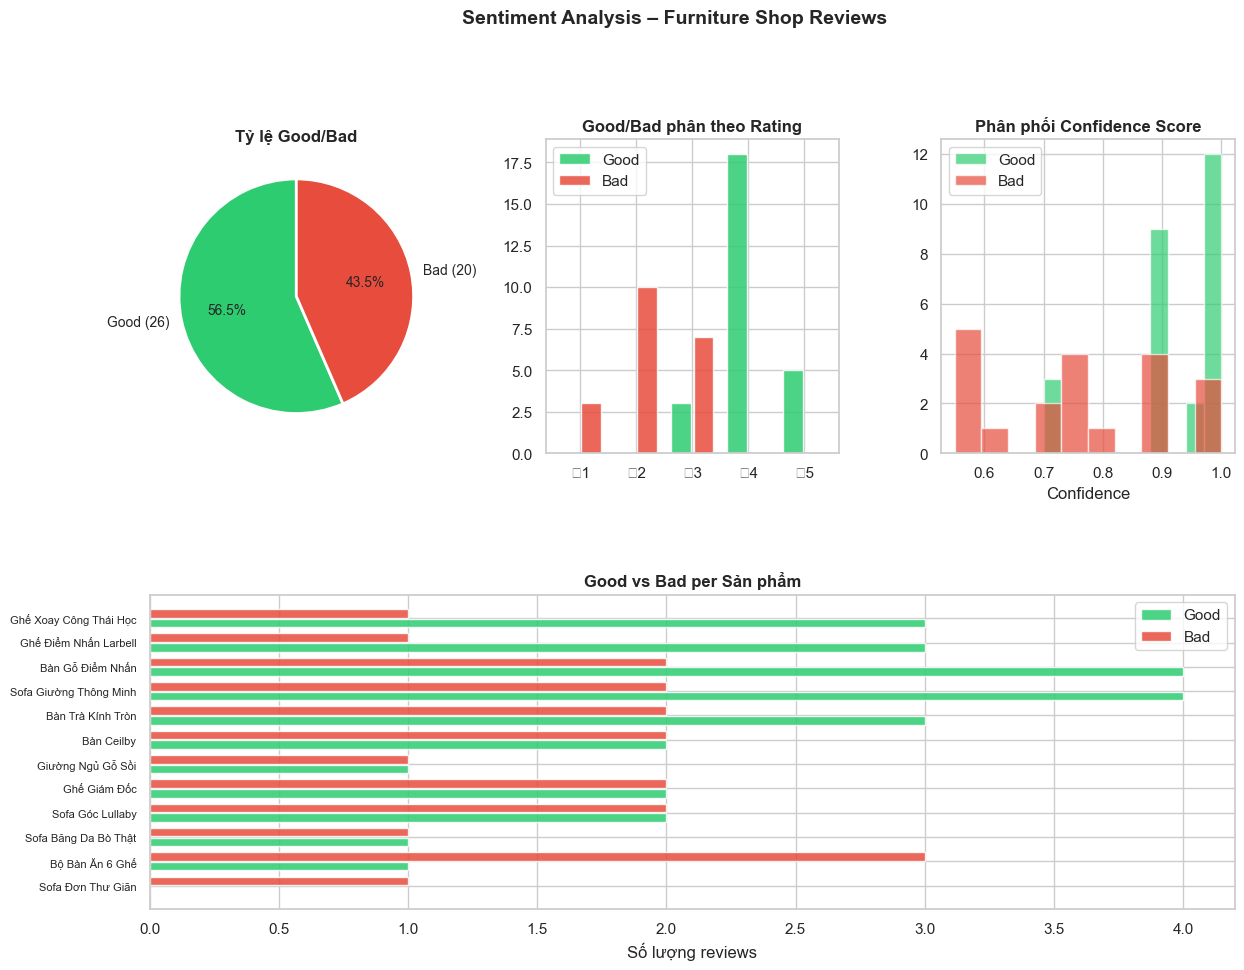

Đã lưu: sentiment_analysis_result.png


In [9]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Pie chart Good/Bad
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie([summary['good'], summary['bad']],
        labels=[f"Good ({summary['good']})", f"Bad ({summary['bad']})"],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
        textprops={'fontsize': 10})
ax1.set_title('Tỷ lệ Good/Bad', fontweight='bold')

# 2. Distribution by rating
ax2 = fig.add_subplot(gs[0, 1])
rating_good = reviews_df[reviews_df['label']=='Good']['rating'].value_counts().sort_index()
rating_bad  = reviews_df[reviews_df['label']=='Bad']['rating'].value_counts().sort_index()
x = np.arange(1, 6)
ax2.bar(x - 0.2, [rating_good.get(r, 0) for r in x], 0.35, label='Good', color='#2ecc71', alpha=0.85)
ax2.bar(x + 0.2, [rating_bad.get(r, 0)  for r in x], 0.35, label='Bad',  color='#e74c3c', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'⭐{r}' for r in x])
ax2.set_title('Good/Bad phân theo Rating', fontweight='bold')
ax2.legend()

# 3. Confidence histogram
ax3 = fig.add_subplot(gs[0, 2])
reviews_df[reviews_df['label']=='Good']['confidence'].hist(bins=10, ax=ax3, color='#2ecc71', alpha=0.7, label='Good')
reviews_df[reviews_df['label']=='Bad']['confidence'].hist(bins=10, ax=ax3, color='#e74c3c', alpha=0.7, label='Bad')
ax3.set_title('Phân phối Confidence Score', fontweight='bold')
ax3.set_xlabel('Confidence')
ax3.legend()

# 4. Per-product analysis
product_names = dict(zip(products_raw['_id'].astype(str), products_raw['name']))
prod_agg = reviews_df.groupby('product_id').agg(
    total=('label','count'),
    good=('label', lambda x: (x=='Good').sum()),
    bad=('label', lambda x: (x=='Bad').sum()),
    avg_rating=('rating','mean'),
    avg_conf=('confidence','mean')
).reset_index()
prod_agg['name']       = prod_agg['product_id'].map(product_names)
prod_agg['good_ratio'] = prod_agg['good'] / prod_agg['total']
prod_agg = prod_agg.sort_values('good_ratio', ascending=True)

ax4 = fig.add_subplot(gs[1, :])
x_prod = np.arange(len(prod_agg))
ax4.barh(x_prod - 0.2, prod_agg['good'],  0.35, label='Good', color='#2ecc71', alpha=0.85)
ax4.barh(x_prod + 0.2, prod_agg['bad'],   0.35, label='Bad',  color='#e74c3c', alpha=0.85)
ax4.set_yticks(x_prod)
ax4.set_yticklabels(prod_agg['name'].str[:30], fontsize=8)
ax4.set_xlabel('Số lượng reviews')
ax4.set_title('Good vs Bad per Sản phẩm', fontweight='bold')
ax4.legend()

plt.suptitle('Sentiment Analysis – Furniture Shop Reviews', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('sentiment_analysis_result.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu: sentiment_analysis_result.png')

## 7. Trend theo thời gian

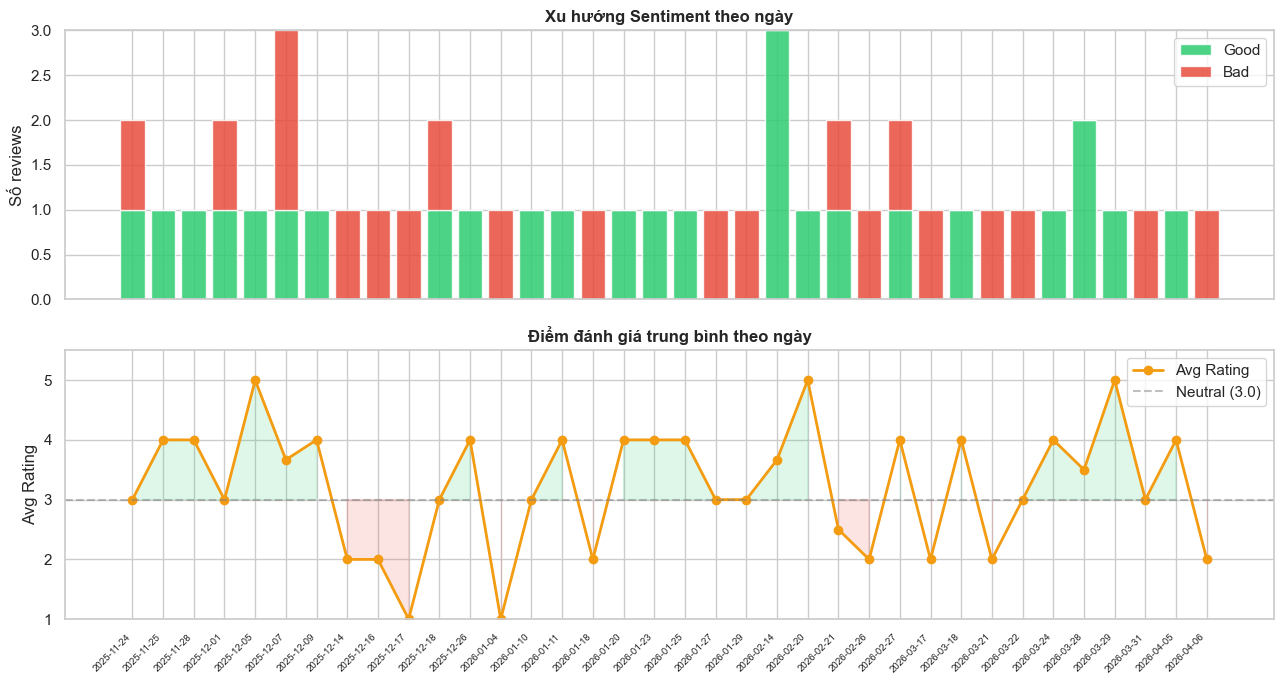

In [10]:
# Merge với created_at
merged = reviews_df.copy()
merged['createdAt'] = pd.to_datetime(reviews_raw['createdAt'].values, errors='coerce')
merged['date'] = merged['createdAt'].dt.strftime('%Y-%m-%d')

trend = (
    merged.dropna(subset=['date'])
    .groupby('date')
    .agg(
        reviews=('review_id','count'),
        avg_rating=('rating','mean'),
        good=('label', lambda x: (x=='Good').sum()),
        bad=('label', lambda x: (x=='Bad').sum()),
    )
    .reset_index()
    .sort_values('date')
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Stacked bar: good/bad per ngày
axes[0].bar(trend['date'], trend['good'], label='Good', color='#2ecc71', alpha=0.85)
axes[0].bar(trend['date'], trend['bad'],  bottom=trend['good'], label='Bad', color='#e74c3c', alpha=0.85)
axes[0].set_title('Xu hướng Sentiment theo ngày', fontweight='bold')
axes[0].set_ylabel('Số reviews')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=7)

# Avg rating line
axes[1].plot(trend['date'], trend['avg_rating'], marker='o', color='#f39c12',
             linewidth=2, markersize=6, label='Avg Rating')
axes[1].axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3.0)')
axes[1].fill_between(trend['date'], 3, trend['avg_rating'],
                     where=trend['avg_rating'] >= 3, alpha=0.15, color='#2ecc71')
axes[1].fill_between(trend['date'], 3, trend['avg_rating'],
                     where=trend['avg_rating'] < 3, alpha=0.15, color='#e74c3c')
axes[1].set_ylim(1, 5.5)
axes[1].set_ylabel('Avg Rating')
axes[1].set_title('Điểm đánh giá trung bình theo ngày', fontweight='bold')
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

## 8. Xem toàn bộ kết quả phân tích

In [11]:
# Kết quả chi tiết với product name
reviews_df['product_name'] = reviews_df['product_id'].map(product_names)

display_cols = ['product_name','rating','comment','label','confidence','score']
reviews_df[display_cols].sort_values(['label','confidence'], ascending=[True, False])

,product_name,rating,comment,label,confidence,score
7,Sofa Băng Da Bò Thật,1.0,"poor finishing, that vong so voi mo ta",Bad,1.00,-3
17,Ghế Điểm Nhấn Larbell,2.0,"poor finishing, that vong so voi mo ta",Bad,1.00,-3
31,Giường Ngủ Gỗ Sồi,1.0,"poor finishing, that vong so voi mo ta",Bad,1.00,-3
8,Sofa Giường Thông Minh,2.0,"worst packaging, nhin hoi xau",Bad,0.90,-2
21,Sofa Góc Lullaby,2.0,"terrible support, giao hang cham va te",Bad,0.90,-2
33,Bàn Gỗ Điểm Nhấn,2.0,"worst packaging, nhin hoi xau",Bad,0.90,-2
40,Ghế Xoay Công Thái Học,2.0,"terrible support, giao hang cham va te",Bad,0.90,-2
10,Sofa Đơn Thư Giãn,1.0,"bad experience, khong hai long voi chat luong",Bad,0.80,-1
5,Ghế Giám Đốc,2.0,"bad experience, khong hai long voi chat luong",Bad,0.75,-1
18,Bàn Trà Kính Tròn,2.0,"bad experience, khong hai long voi chat luong",Bad,0.75,-1


## 9. Tóm tắt luồng xử lý

In [12]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           Sentiment Analysis – Luồng Xử Lý                       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  INPUT: reviews[{_id, product, user, rating, comment}]           ║
║                                                                  ║
║  sentiment_label(comment, rating):                               ║
║    1. text = comment.lower()                                     ║
║    2. score = Σ(hit_positive) - Σ(hit_negative)                  ║
║    3. if rating≥4 and score≥-1   → label='Good'                  ║
║       elif rating≤2 and score≤1  → label='Bad'                   ║
║       elif score > 0             → label='Good'                  ║
║       else                       → label='Bad'                   ║
║    4. confidence = min(1.0,                                      ║
║           0.55 + |score|×0.15 + |rating-3.0|×0.05)               ║
║                                                                  ║
║  sentiment_analysis(reviews):                                    ║
║    → Loop → {review_id, product_id, label, confidence, score}    ║
║    → summary: {total, good, bad, good_ratio, bad_ratio}          ║
║                                                                  ║
║  OUTPUT: {summary:{...}, reviews:[...]}                          ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           Sentiment Analysis – Luồng Xử Lý                       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  INPUT: reviews[{_id, product, user, rating, comment}]           ║
║                                                                  ║
║  sentiment_label(comment, rating):                               ║
║    1. text = comment.lower()                                     ║
║    2. score = Σ(hit_positive) - Σ(hit_negative)                  ║
║    3. if rating≥4 and score≥-1   → label='Good'                  ║
║       elif rating≤2 and score≤1  → label='Bad'                   ║
║       elif score > 0             → label='Good'                  ║
║       else                       → label='Bad'                   ║
║    4. confidence = min(1.0,                                      ║
║           0.55 + |score|×0.15 +